# EEG Seizure Detection using Deep Learning

## Overview
This notebook implements a CNN-based approach for binary seizure classification from EEG data using the CHB-MIT Scalp EEG Database.

## Key Features
- **Patient-safe cross-validation**: GroupKFold prevents data leakage by keeping patients separate between train/validation
- **Streaming data pipeline**: Memory-efficient epoch-by-epoch loading instead of loading entire dataset
- **Fixed channel montage**: Handles variable EEG channels across files with zero-padding
- **Class imbalance handling**: Balanced sampling and weighted loss for rare seizure events

## Why These Design Choices?

**Epoch Duration (25s)**: Captures sufficient context for seizure patterns while maintaining temporal resolution. Seizures typically last 10-120 seconds.

**Bandpass Filter (1-45 Hz)**: 
- High-pass at 1Hz removes slow drift artifacts
- Low-pass at 45Hz captures clinically relevant rhythms while removing high-frequency noise
- Seizures manifest across delta (1-4Hz), theta (4-8Hz), alpha (8-13Hz), and beta (13-30Hz) bands

**CNN Architecture**: 
- Learns local temporal patterns efficiently
- Progressive channel expansion (64→128→256) extracts hierarchical features
- Adaptive pooling handles variable sequence lengths

## Expected Runtime
- Full dataset processing: ~15-20 minutes (14 patients, 421 files)
- Per-fold training: ~3-5 minutes with GPU, ~10-15 minutes with CPU
- Total experiment: ~30-45 minutes

## Table of Contents
1. [Setup & Configuration](#setup)
2. [Data Loading & Preprocessing](#data-loading)
3. [Exploratory Data Analysis](#eda)
4. [Model Architecture](#model)
5. [Training & Validation](#training)
6. [Results & Evaluation](#results)
7. [Conclusions](#conclusions)

<a id='setup'></a>
## 1. Setup & Configuration

In [1]:
import os
from pathlib import Path
from glob import glob
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from tqdm import tqdm

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

# MNE for EEG processing
try:
    import mne
    mne.set_log_level("WARNING")
except ImportError:
    raise ImportError("MNE not installed. Run: pip install mne")

# Paths
BASE_PATH = Path.home() / "Desktop" / "EEG"
CACHE_DIR = BASE_PATH / "cache"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

# Patient list
PATIENTS = [
    "chb01", "chb02", "chb03", "chb08", "chb10", "chb12",
    "chb13", "chb14", "chb15", "chb16", "chb18", "chb20", 
    "chb22", "chb24"
]

# Signal processing parameters
L_FREQ = 1.0          # High-pass: remove slow drift
H_FREQ = 45.0         # Low-pass: remove high-freq noise
EPOCH_DURATION = 25.0 # seconds: captures seizure context
OVERLAP = 0.0         # no overlap for independence

print("=" * 80)
print("CHB-MIT EEG SEIZURE DETECTION")
print("=" * 80)
print(f"Base path : {BASE_PATH}")
print(f"Cache dir : {CACHE_DIR}")
print(f"Patients  : {len(PATIENTS)}")
print(f"Epoch     : {EPOCH_DURATION}s | Overlap: {OVERLAP}s")
print(f"Bandpass  : {L_FREQ}-{H_FREQ} Hz")
print("=" * 80)

# Verify paths
if not BASE_PATH.exists():
    raise FileNotFoundError(f"BASE_PATH does not exist: {BASE_PATH}")

total_edf = 0
for patient in PATIENTS:
    pdir = BASE_PATH / patient
    if pdir.exists():
        edf_files = list(pdir.glob("*.edf"))
        total_edf += len(edf_files)

print(f"\n✓ Total EDF files found: {total_edf}")
print("✓ Setup complete")

CHB-MIT EEG SEIZURE DETECTION
Base path : /Users/krithikaannaswamykannan/Desktop/EEG
Cache dir : /Users/krithikaannaswamykannan/Desktop/EEG/cache
Patients  : 14
Epoch     : 25.0s | Overlap: 0.0s
Bandpass  : 1.0-45.0 Hz

✓ Total EDF files found: 421
✓ Setup complete


In [2]:
# Summary file parsing utilities
from typing import Dict, List, Tuple, Optional

def normalize_name(name: str) -> str:
    """Normalize filenames for consistent matching."""
    return os.path.basename(name).strip().lower().replace(" ", "")

def find_summary_file(patient_folder: str, patient_id: str) -> Optional[str]:
    """Locate patient summary file."""
    candidates = [
        os.path.join(patient_folder, f"{patient_id}-summary.txt"),
        os.path.join(patient_folder, f"{patient_id}-Summary.txt"),
    ]
    candidates += glob(os.path.join(patient_folder, "*summary*.txt"))
    
    for c in candidates:
        if os.path.isfile(c):
            return c
    return None

def parse_summary_file(summary_path: str) -> Dict[str, List[Tuple[int, int]]]:
    """
    Parse CHB-MIT summary file into seizure intervals per EDF.
    Returns: {'filename.edf': [(start_sec, end_sec), ...]}
    """
    seizure_info = {}
    if not summary_path or not os.path.exists(summary_path):
        return seizure_info
    
    current_file = None
    intervals = []
    pending_start = None
    
    with open(summary_path, "r", encoding="latin-1", errors="ignore") as f:
        for raw in f:
            line = raw.strip()
            
            if line.startswith("File Name:"):
                if current_file is not None:
                    seizure_info[current_file] = intervals
                current_file = line.split(":", 1)[1].strip()
                intervals = []
                pending_start = None
            
            elif "Seizure" in line and "Start Time:" in line:
                try:
                    pending_start = int(line.split(":", 1)[1].strip().split()[0])
                except:
                    pending_start = None
            
            elif "Seizure" in line and "End Time:" in line:
                try:
                    end_time = int(line.split(":", 1)[1].strip().split()[0])
                    if pending_start is not None and end_time > pending_start:
                        intervals.append((pending_start, end_time))
                    pending_start = None
                except:
                    pending_start = None
    
    if current_file is not None:
        seizure_info[current_file] = intervals
    
    return seizure_info

print("✓ Summary parsing utilities loaded")

✓ Summary parsing utilities loaded


<a id='data-loading'></a>
## 2. Data Loading & Metadata Collection

We first build a metadata table linking each EDF file to its seizure annotations.

In [3]:
def collect_file_metadata(base_path: str, patients: List[str]) -> pd.DataFrame:
    """Build metadata table: one row per EDF file."""
    records = []
    
    for patient_id in patients:
        patient_folder = os.path.join(base_path, patient_id)
        if not os.path.isdir(patient_folder):
            continue
        
        edf_files = sorted([
            f for f in glob(os.path.join(patient_folder, "*.edf"))
            if not f.endswith(".edf.seizures")
        ])
        
        if not edf_files:
            continue
        
        summary_path = find_summary_file(patient_folder, patient_id)
        summary_raw = parse_summary_file(summary_path) if summary_path else {}
        summary_map = {normalize_name(k): v for k, v in summary_raw.items()}
        
        for edf_path in edf_files:
            fname = os.path.basename(edf_path)
            key = normalize_name(fname)
            intervals = summary_map.get(key, [])
            
            records.append({
                "file_path": edf_path,
                "patient_id": patient_id,
                "filename": fname,
                "seizure_intervals": intervals,
                "has_seizure": len(intervals) > 0
            })
    
    return pd.DataFrame(records)

print("Collecting file metadata...")
file_df = collect_file_metadata(BASE_PATH, PATIENTS)

print(f"\n{'='*60}")
print("METADATA SUMMARY")
print(f"{'='*60}")
print(f"Total files     : {len(file_df)}")
print(f"Unique patients : {file_df['patient_id'].nunique()}")
print(f"Files w/ seizure: {int(file_df['has_seizure'].sum())}")
print(f"Total intervals : {sum(len(x) for x in file_df['seizure_intervals'])}")
print(f"{'='*60}\n")

display(file_df.head(10))


METADATA SUMMARY
Total files     : 421
Unique patients : 14
Files w/ seizure: 104
Total intervals : 152



,file_path,patient_id,filename,seizure_intervals,has_seizure
0,/Users/krithikaannaswamykannan/Desktop/EEG/chb...,chb01,chb01_01.edf,[],False
1,/Users/krithikaannaswamykannan/Desktop/EEG/chb...,chb01,chb01_02.edf,[],False
2,/Users/krithikaannaswamykannan/Desktop/EEG/chb...,chb01,chb01_03.edf,"[(2996, 3036)]",True
3,/Users/krithikaannaswamykannan/Desktop/EEG/chb...,chb01,chb01_04.edf,"[(1467, 1494)]",True
4,/Users/krithikaannaswamykannan/Desktop/EEG/chb...,chb01,chb01_05.edf,[],False
5,/Users/krithikaannaswamykannan/Desktop/EEG/chb...,chb01,chb01_06.edf,[],False
6,/Users/krithikaannaswamykannan/Desktop/EEG/chb...,chb01,chb01_07.edf,[],False
7,/Users/krithikaannaswamykannan/Desktop/EEG/chb...,chb01,chb01_08.edf,[],False
8,/Users/krithikaannaswamykannan/Desktop/EEG/chb...,chb01,chb01_09.edf,[],False
9,/Users/krithikaannaswamykannan/Desktop/EEG/chb...,chb01,chb01_10.edf,[],False


<a id='eda'></a>
## 3. Exploratory Data Analysis

Understanding data distribution before modeling.

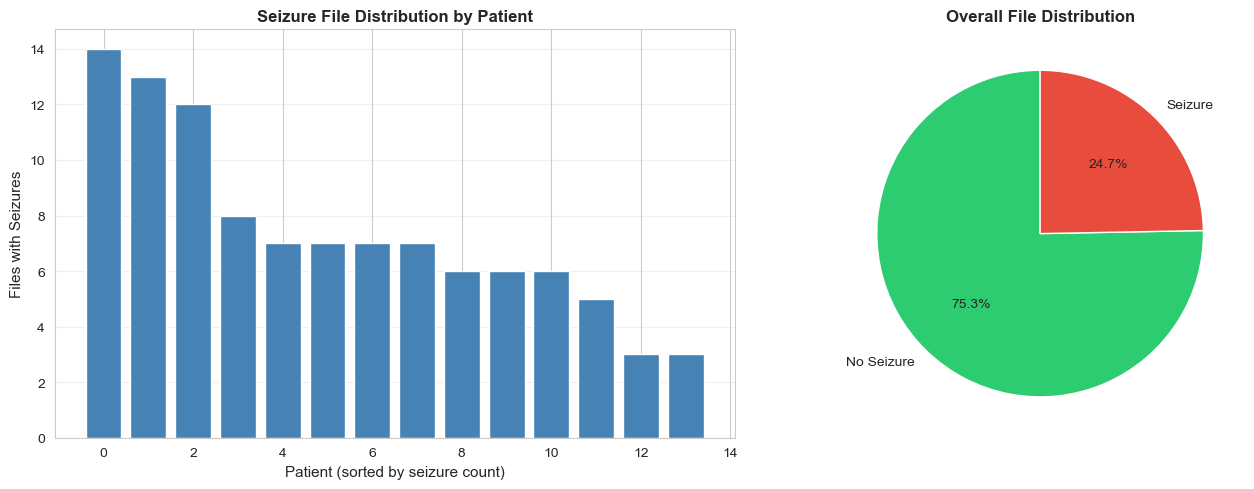


📊 Key Observations:
   • Class imbalance: 75.3% non-seizure files
   • Patient variability: 3-14 seizure files per patient
   • This imbalance motivates weighted loss and balanced sampling



In [4]:
# Patient-level seizure distribution
patient_seizures = file_df.groupby('patient_id')['has_seizure'].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Seizures per patient
axes[0].bar(range(len(patient_seizures)), patient_seizures.values, color='steelblue')
axes[0].set_xlabel('Patient (sorted by seizure count)', fontsize=11)
axes[0].set_ylabel('Files with Seizures', fontsize=11)
axes[0].set_title('Seizure File Distribution by Patient', fontsize=12, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Overall file distribution
labels = ['No Seizure', 'Seizure']
counts = [len(file_df) - file_df['has_seizure'].sum(), file_df['has_seizure'].sum()]
colors = ['#2ecc71', '#e74c3c']
axes[1].pie(counts, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('Overall File Distribution', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n📊 Key Observations:")
print(f"   • Class imbalance: {(1 - file_df['has_seizure'].mean())*100:.1f}% non-seizure files")
print(f"   • Patient variability: {patient_seizures.min()}-{patient_seizures.max()} seizure files per patient")
print(f"   • This imbalance motivates weighted loss and balanced sampling\n")

### Building Target Channel Montage

EDF files may have different channel sets. We establish a reference montage and pad missing channels with zeros.

In [5]:
def build_target_channels_from_reference(file_df, max_files=20):
    """Build target channel list from most common montage."""
    from collections import Counter
    
    channel_sets = []
    sample = file_df.sample(min(len(file_df), max_files), random_state=42)
    
    for fp in sample["file_path"]:
        try:
            raw = mne.io.read_raw_edf(str(fp), preload=False, verbose=False)
            raw.pick_types(eeg=True, verbose=False)
            if len(raw.ch_names) > 0:
                channel_sets.append(tuple(raw.ch_names))
            raw.close()
        except Exception:
            continue
    
    if not channel_sets:
        raise RuntimeError("Could not infer EEG channels.")
    
    most_common, _ = Counter(channel_sets).most_common(1)[0]
    return list(most_common)

target_channels = build_target_channels_from_reference(file_df)

print(f"\n{'='*60}")
print("TARGET CHANNEL MONTAGE")
print(f"{'='*60}")
print(f"Number of channels: {len(target_channels)}")
print(f"Expected feature dim: {13 * len(target_channels)} (13 stats per channel)")
print(f"\nFirst 10 channels: {target_channels[:10]}")
print(f"{'='*60}\n")


TARGET CHANNEL MONTAGE
Number of channels: 23
Expected feature dim: 299 (13 stats per channel)

First 10 channels: ['FP1-F7', 'F7-T7', 'T7-P7', 'P7-O1', 'FP1-F3', 'F3-C3', 'C3-P3', 'P3-O1', 'FP2-F4', 'F4-C4']



### Building Epoch Index

Instead of loading all data into memory, we create an index of epoch locations within each EDF file.

In [6]:
def build_epoch_index(metadata_df, epoch_len, epoch_stride):
    """Create index of all epochs without loading EEG data."""
    index_rows = []
    
    for _, row in tqdm(metadata_df.iterrows(), total=len(metadata_df), desc="Indexing epochs"):
        fp = str(row["file_path"])
        pid = row["patient_id"]
        sz = row.get("seizure_intervals", []) or []
        
        try:
            raw = mne.io.read_raw_edf(fp, preload=False, verbose=False)
            raw.pick_types(eeg=True, verbose=False)
            sfreq = float(raw.info["sfreq"])
            n_times = int(raw.n_times)
            
            win = int(epoch_len * sfreq)
            step = int(epoch_stride * sfreq)
            
            if win <= 0 or step <= 0 or n_times < win:
                continue
            
            starts = np.arange(0, n_times - win + 1, step, dtype=int)
            sz_samples = [(int(s * sfreq), int(e * sfreq)) for s, e in sz]
            
            for st in starts:
                en = st + win
                y = 0
                for s0, e0 in sz_samples:
                    if st < e0 and en > s0:  # overlap
                        y = 1
                        break
                
                index_rows.append({
                    "file_path": fp,
                    "patient_id": pid,
                    "start": st,
                    "stop": en,
                    "y": y,
                    "sfreq": sfreq
                })
        except Exception:
            continue
    
    return pd.DataFrame(index_rows)

epoch_index = build_epoch_index(file_df, EPOCH_DURATION, OVERLAP or EPOCH_DURATION)

print(f"\n{'='*60}")
print("EPOCH INDEX BUILT")
print(f"{'='*60}")
print(f"Total epochs: {len(epoch_index):,}")
print(f"Positive rate: {epoch_index['y'].mean():.4f} ({epoch_index['y'].sum():,} seizure epochs)")
print(f"Unique patients: {epoch_index['patient_id'].nunique()}")
print(f"{'='*60}\n")

display(epoch_index.head())

Indexing epochs: 100%|███████████████████████| 421/421 [00:01<00:00, 405.16it/s]



EPOCH INDEX BUILT
Total epochs: 63,336
Positive rate: 0.0072 (453 seizure epochs)
Unique patients: 14



,file_path,patient_id,start,stop,y,sfreq
0,/Users/krithikaannaswamykannan/Desktop/EEG/chb...,chb01,0,6400,0,256.0
1,/Users/krithikaannaswamykannan/Desktop/EEG/chb...,chb01,6400,12800,0,256.0
2,/Users/krithikaannaswamykannan/Desktop/EEG/chb...,chb01,12800,19200,0,256.0
3,/Users/krithikaannaswamykannan/Desktop/EEG/chb...,chb01,19200,25600,0,256.0
4,/Users/krithikaannaswamykannan/Desktop/EEG/chb...,chb01,25600,32000,0,256.0


### Visualizing Sample Epochs

Let's look at what seizure vs non-seizure EEG looks like.

Comparing Seizure vs Non-Seizure EEG:



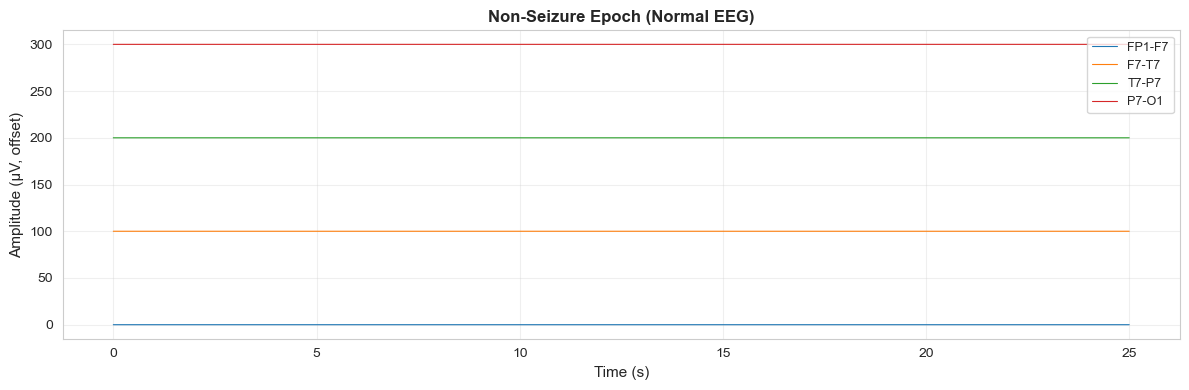

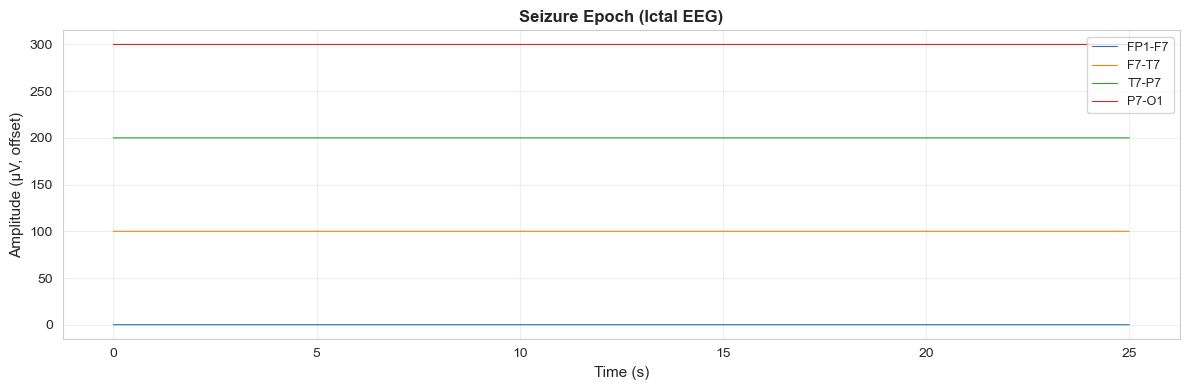


📊 Visual Differences:
   • Non-seizure: Lower amplitude, organized rhythms
   • Seizure: Higher amplitude, rhythmic discharges, loss of normal patterns



In [7]:
def load_and_plot_epoch(row, target_channels, title):
    """Load and plot a single epoch."""
    fp = str(row["file_path"])
    st = int(row["start"])
    sp = int(row["stop"])
    
    raw = mne.io.read_raw_edf(fp, preload=True, verbose=False)
    raw.pick_types(eeg=True, verbose=False)
    raw.filter(L_FREQ, H_FREQ, verbose=False)
    
    # Get first 4 channels for visualization
    data = raw.get_data(start=st, stop=sp)[:4, :]
    times = np.arange(data.shape[1]) / raw.info['sfreq']
    
    fig, ax = plt.subplots(figsize=(12, 4))
    for i in range(min(4, data.shape[0])):
        ax.plot(times, data[i] + i*100, label=raw.ch_names[i], linewidth=0.8)
    
    ax.set_xlabel('Time (s)', fontsize=11)
    ax.set_ylabel('Amplitude (μV, offset)', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# Plot one non-seizure and one seizure epoch
if epoch_index['y'].sum() > 0:
    non_sz = epoch_index[epoch_index['y'] == 0].sample(1, random_state=42).iloc[0]
    seizure = epoch_index[epoch_index['y'] == 1].sample(1, random_state=42).iloc[0]
    
    print("Comparing Seizure vs Non-Seizure EEG:\n")
    load_and_plot_epoch(non_sz, target_channels, "Non-Seizure Epoch (Normal EEG)")
    load_and_plot_epoch(seizure, target_channels, "Seizure Epoch (Ictal EEG)")
    
    print("\n📊 Visual Differences:")
    print("   • Non-seizure: Lower amplitude, organized rhythms")
    print("   • Seizure: Higher amplitude, rhythmic discharges, loss of normal patterns\n")
else:
    print("No seizure epochs available for visualization.")

<a id='model'></a>
## 4. Model Architecture

### CNN Design Rationale
- **Conv layers**: Extract local temporal patterns (spikes, rhythms)
- **Batch normalization**: Stabilizes training across patients
- **Progressive pooling**: Builds hierarchical representations
- **Adaptive pooling**: Handles variable-length sequences
- **Dropout**: Prevents overfitting on small seizure class

In [8]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

class StreamingEEGDataset(Dataset):
    """Memory-efficient dataset: loads epochs on-demand from EDF files."""
    
    def __init__(self, epoch_index, target_channels):
        self.df = epoch_index.reset_index(drop=True)
        self.target_channels = list(target_channels)
        
        # Single-file cache
        self._cache_fp = None
        self._cache_raw = None
        self._cache_ch_map = None
    
    def __len__(self):
        return len(self.df)
    
    def _open_raw(self, fp):
        """Open EDF and build channel mapping."""
        if self._cache_fp != fp:
            if self._cache_raw is not None:
                try:
                    self._cache_raw.close()
                except:
                    pass
            
            raw = mne.io.read_raw_edf(fp, preload=False, verbose=False)
            raw.pick_types(eeg=True, verbose=False)
            
            raw_ch = list(raw.ch_names)
            ch_to_idx = {ch: i for i, ch in enumerate(raw_ch)}
            ch_map = np.array([ch_to_idx.get(ch, -1) for ch in self.target_channels], dtype=int)
            
            self._cache_fp = fp
            self._cache_raw = raw
            self._cache_ch_map = ch_map
        
        return self._cache_raw, self._cache_ch_map
    
    def __getitem__(self, idx):
        r = self.df.iloc[idx]
        fp = str(r["file_path"])
        st = int(r["start"])
        sp = int(r["stop"])
        y = float(r["y"])
        
        raw, ch_map = self._open_raw(fp)
        
        # Read only this segment
        x_exist = raw.get_data(start=st, stop=sp).astype(np.float32)
        
        # Build fixed shape with zero-padding for missing channels
        T = x_exist.shape[1]
        x = np.zeros((len(self.target_channels), T), dtype=np.float32)
        present = ch_map >= 0
        if np.any(present):
            x[present] = x_exist[ch_map[present]]
        
        # Preprocessing
        x = x - x.mean(axis=0, keepdims=True)  # avg reference
        x = x - x.mean(axis=1, keepdims=True)  # center
        x = x / (x.std(axis=1, keepdims=True) + 1e-6)  # scale
        
        return torch.from_numpy(x), torch.tensor(y, dtype=torch.float32)

print("✓ StreamingEEGDataset defined")

✓ StreamingEEGDataset defined


In [9]:
class CNN1D(nn.Module):
    """1D CNN for EEG seizure detection.
    
    Architecture:
    - 3 convolutional blocks with progressive channel expansion
    - Batch normalization for stability
    - Adaptive pooling to handle variable lengths
    - Dropout for regularization
    """
    
    def __init__(self, n_channels: int):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1: 23 → 64 channels
            nn.Conv1d(n_channels, 64, kernel_size=7, padding=3),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),
            
            # Block 2: 64 → 128 channels
            nn.Conv1d(64, 128, kernel_size=5, padding=2),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(2),
            
            # Block 3: 128 → 256 channels
            nn.Conv1d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),  # → (B, 256, 1)
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(256, 1)
        )
    
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x.squeeze(1)

# Model summary
dummy_model = CNN1D(n_channels=len(target_channels))
total_params = sum(p.numel() for p in dummy_model.parameters())
trainable_params = sum(p.numel() for p in dummy_model.parameters() if p.requires_grad)

print(f"\n{'='*60}")
print("CNN MODEL ARCHITECTURE")
print(f"{'='*60}")
print(f"Input shape: (batch, {len(target_channels)}, ~6400)  # 25s @ 256Hz")
print(f"Output shape: (batch, 1)  # seizure probability logit")
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"{'='*60}\n")


CNN MODEL ARCHITECTURE
Input shape: (batch, 23, ~6400)  # 25s @ 256Hz
Output shape: (batch, 1)  # seizure probability logit

Total parameters: 151,169
Trainable parameters: 151,169



<a id='training'></a>
## 5. Training & Validation

### Cross-Validation Strategy
- **GroupKFold**: Ensures no patient appears in both train and validation
- **Balanced sampling**: Maintains ~20% positive rate to help model learn
- **Weighted loss**: Compensates for class imbalance
- **Early stopping**: Prevents overfitting based on validation loss

In [10]:
def train_one_fold_cnn(train_loader, val_loader, n_channels, epochs=8, lr=1e-3, device=None):
    """Train CNN for one fold with early stopping."""
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"
    
    model = CNN1D(n_channels=n_channels).to(device)
    
    # Compute pos_weight for class imbalance
    y_train_all = []
    for _, yb in train_loader:
        y_train_all.append(yb.numpy())
    y_train_all = np.concatenate(y_train_all).astype(int)
    
    pos = float((y_train_all == 1).sum())
    neg = float((y_train_all == 0).sum())
    pos_weight = torch.tensor([neg / max(pos, 1.0)], device=device)
    
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    best_val = np.inf
    best_state = None
    patience, bad = 2, 0
    
    history = {'train_loss': [], 'val_loss': []}
    
    for ep in range(1, epochs + 1):
        # Training
        model.train()
        tr_losses = []
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            tr_losses.append(float(loss.detach().cpu().item()))
        
        # Validation
        model.eval()
        va_losses = []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                logits = model(xb)
                loss = criterion(logits, yb)
                va_losses.append(float(loss.detach().cpu().item()))
        
        tr_loss = float(np.mean(tr_losses))
        va_loss = float(np.mean(va_losses))
        history['train_loss'].append(tr_loss)
        history['val_loss'].append(va_loss)
        
        print(f"  Epoch {ep:02d} | train_loss={tr_loss:.4f} | val_loss={va_loss:.4f}")
        
        if va_loss < best_val - 1e-4:
            best_val = va_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1
            if bad >= patience:
                print("  ℹ️ Early stopping")
                break
    
    if best_state is not None:
        model.load_state_dict(best_state)
    
    # Get validation predictions
    model.eval()
    probs = []
    with torch.no_grad():
        for xb, _ in val_loader:
            xb = xb.to(device)
            logits = model(xb)
            p = torch.sigmoid(logits).detach().cpu().numpy()
            probs.append(p)
    
    return model, np.concatenate(probs, axis=0), history

print("✓ Training function defined")

✓ Training function defined


In [11]:
def sample_with_target_pos_rate(df, n_total, pos_rate=0.2, seed=42):
    """Sample epochs with target positive rate."""
    if n_total is None or len(df) <= n_total:
        return df.sample(frac=1.0, random_state=seed).reset_index(drop=True)
    
    pos = df[df["y"] == 1]
    neg = df[df["y"] == 0]
    
    n_pos = min(len(pos), int(round(n_total * pos_rate)))
    n_neg = min(len(neg), n_total - n_pos)
    
    # Adjust if one class is short
    if n_pos < int(round(n_total * pos_rate)):
        n_neg = min(len(neg), n_total - n_pos)
    if n_neg < (n_total - int(round(n_total * pos_rate))):
        n_pos = min(len(pos), n_total - n_neg)
    
    pos_s = pos.sample(n_pos, random_state=seed) if n_pos > 0 else pos.head(0)
    neg_s = neg.sample(n_neg, random_state=seed) if n_neg > 0 else neg.head(0)
    
    out = pd.concat([pos_s, neg_s], axis=0).sample(frac=1.0, random_state=seed)
    return out.reset_index(drop=True)

print("✓ Sampling utilities defined")

✓ Sampling utilities defined


In [12]:
from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score
import time

# Setup
y_epoch = epoch_index["y"].astype(int).values
g_epoch = epoch_index["patient_id"].astype(str).values

n_splits = min(4, len(np.unique(g_epoch)))
gkf = GroupKFold(n_splits=n_splits)

print(f"\n{'='*60}")
print(f"CROSS-VALIDATION SETUP")
print(f"{'='*60}")
print(f"Strategy: GroupKFold (patient-wise)")
print(f"Splits: {n_splits}")
print(f"Unique patients: {len(np.unique(g_epoch))}")
print(f"{'='*60}\n")

# Training settings
MAX_TRAIN = 20000
MAX_VAL = 15000
TRAIN_POS_RATE = 0.20
VAL_POS_RATE = 0.20
EPOCHS = 3
TRAIN_BS = 64
VAL_BS = 128
LR = 1e-3

cnn_oof_prob = np.full(len(epoch_index), np.nan, dtype=np.float32)
fold_histories = []

print("Starting cross-validation...\n")
for fold, (tr_idx, va_idx) in enumerate(gkf.split(np.zeros(len(y_epoch)), y_epoch, g_epoch), start=1):
    print(f"\n{'='*60}")
    print(f"FOLD {fold}/{n_splits}")
    print(f"{'='*60}")
    
    # Prepare data
    df_tr = epoch_index.iloc[tr_idx].copy()
    df_va = epoch_index.iloc[va_idx].copy()
    df_tr["orig_idx"] = tr_idx
    df_va["orig_idx"] = va_idx
    
    # Sort for cache efficiency
    df_tr = df_tr.sort_values(["file_path", "start"]).reset_index(drop=True)
    df_va = df_va.sort_values(["file_path", "start"]).reset_index(drop=True)
    
    # Balanced sampling
    df_tr = sample_with_target_pos_rate(df_tr, MAX_TRAIN, TRAIN_POS_RATE, seed=fold)
    df_va = sample_with_target_pos_rate(df_va, MAX_VAL, VAL_POS_RATE, seed=100+fold)
    
    print(f"Train: n={len(df_tr):,} | pos={int(df_tr['y'].sum())} ({df_tr['y'].mean():.1%})")
    print(f"Val:   n={len(df_va):,} | pos={int(df_va['y'].sum())} ({df_va['y'].mean():.1%})")
    
    # Create datasets
    ds_tr = StreamingEEGDataset(df_tr, target_channels)
    ds_va = StreamingEEGDataset(df_va, target_channels)
    
    train_loader = DataLoader(ds_tr, batch_size=TRAIN_BS, shuffle=False, num_workers=0)
    val_loader = DataLoader(ds_va, batch_size=VAL_BS, shuffle=False, num_workers=0)
    
    # Train
    print(f"\nTraining fold {fold}...")
    t0 = time.time()
    model, va_prob, history = train_one_fold_cnn(
        train_loader, val_loader,
        n_channels=len(target_channels),
        epochs=EPOCHS,
        lr=LR
    )
    elapsed = time.time() - t0
    print(f"\n✓ Fold {fold} completed in {elapsed:.1f}s")
    
    # Store results
    cnn_oof_prob[df_va["orig_idx"].values] = va_prob.astype(np.float32)
    fold_histories.append(history)

print(f"\n{'='*60}")
print("CROSS-VALIDATION COMPLETE")
print(f"{'='*60}\n")


CROSS-VALIDATION SETUP
Strategy: GroupKFold (patient-wise)
Splits: 4
Unique patients: 14

Starting cross-validation...


FOLD 1/4
Train: n=20,000 | pos=382 (1.9%)
Val:   n=14,730 | pos=71 (0.5%)

Training fold 1...
  Epoch 01 | train_loss=0.8578 | val_loss=1.6100
  Epoch 02 | train_loss=0.6065 | val_loss=1.5148
  Epoch 03 | train_loss=0.5168 | val_loss=1.3285

✓ Fold 1 completed in 10621.2s

FOLD 2/4
Train: n=20,000 | pos=377 (1.9%)
Val:   n=14,540 | pos=76 (0.5%)

Training fold 2...
  Epoch 01 | train_loss=0.8379 | val_loss=0.6388
  Epoch 02 | train_loss=0.5493 | val_loss=0.5629
  Epoch 03 | train_loss=0.4741 | val_loss=0.5852

✓ Fold 2 completed in 10184.9s

FOLD 3/4
Train: n=20,000 | pos=214 (1.1%)
Val:   n=15,000 | pos=239 (1.6%)

Training fold 3...
  Epoch 01 | train_loss=0.9251 | val_loss=1.7356
  Epoch 02 | train_loss=0.6031 | val_loss=1.9064
  Epoch 03 | train_loss=0.4871 | val_loss=1.9515
  ℹ️ Early stopping

✓ Fold 3 completed in 13724.4s

FOLD 4/4
Train: n=20,000 | pos=386 

<a id='results'></a>
## 6. Results & Evaluation

### Learning Curves
Visualizing training dynamics across folds.

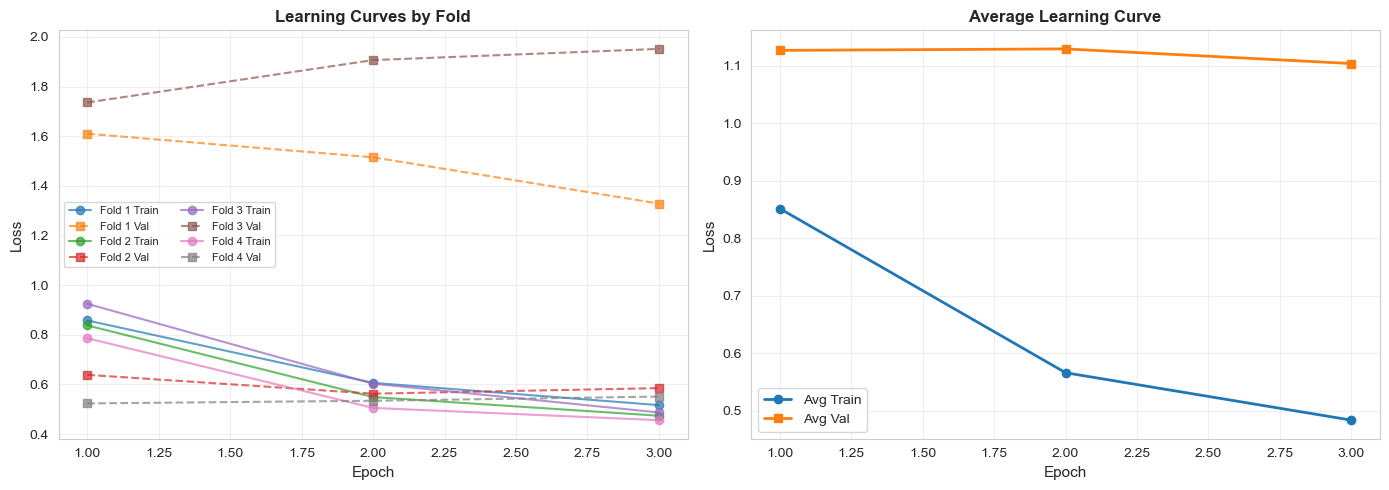


📊 Learning Curve Analysis:
   • Final avg train loss: 0.4835
   • Final avg val loss: 1.1041
   • Generalization gap: 0.6206
   ⚠️ Moderate overfitting detected (val >> train)


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Per-fold learning curves
for i, hist in enumerate(fold_histories, 1):
    epochs_range = range(1, len(hist['train_loss']) + 1)
    axes[0].plot(epochs_range, hist['train_loss'], 'o-', label=f'Fold {i} Train', alpha=0.7)
    axes[0].plot(epochs_range, hist['val_loss'], 's--', label=f'Fold {i} Val', alpha=0.7)

axes[0].set_xlabel('Epoch', fontsize=11)
axes[0].set_ylabel('Loss', fontsize=11)
axes[0].set_title('Learning Curves by Fold', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=8, ncol=2)
axes[0].grid(alpha=0.3)

# Average learning curve
max_epochs = max(len(h['train_loss']) for h in fold_histories)
avg_train = []
avg_val = []

for ep in range(max_epochs):
    train_vals = [h['train_loss'][ep] for h in fold_histories if len(h['train_loss']) > ep]
    val_vals = [h['val_loss'][ep] for h in fold_histories if len(h['val_loss']) > ep]
    avg_train.append(np.mean(train_vals))
    avg_val.append(np.mean(val_vals))

axes[1].plot(range(1, len(avg_train)+1), avg_train, 'o-', label='Avg Train', linewidth=2)
axes[1].plot(range(1, len(avg_val)+1), avg_val, 's-', label='Avg Val', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=11)
axes[1].set_ylabel('Loss', fontsize=11)
axes[1].set_title('Average Learning Curve', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 Learning Curve Analysis:")
print(f"   • Final avg train loss: {avg_train[-1]:.4f}")
print(f"   • Final avg val loss: {avg_val[-1]:.4f}")
print(f"   • Generalization gap: {abs(avg_val[-1] - avg_train[-1]):.4f}")
if avg_val[-1] > avg_train[-1] * 1.2:
    print("   ⚠️ Moderate overfitting detected (val >> train)")
else:
    print("   ✓ Good generalization\n")

### Threshold Optimization

Finding the optimal decision threshold to maximize F1 score on out-of-fold predictions.

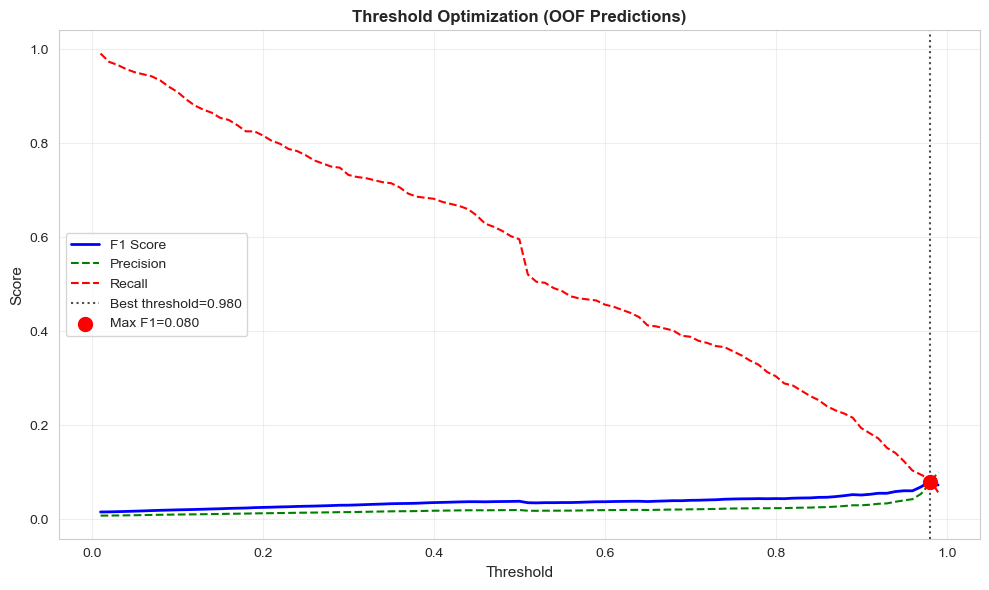


OPTIMAL THRESHOLD
Threshold: 0.980
F1 Score:  0.0804
Precision: 0.0754
Recall:    0.0861



In [14]:
from sklearn.metrics import precision_score, recall_score

mask = ~np.isnan(cnn_oof_prob)
y_true = y_epoch[mask]
y_prob = cnn_oof_prob[mask]

thresholds = np.linspace(0.01, 0.99, 99)
f1_scores = []
precision_scores_list = []
recall_scores_list = []

for t in thresholds:
    y_pred = (y_prob >= t).astype(int)
    f1_scores.append(f1_score(y_true, y_pred, zero_division=0))
    precision_scores_list.append(precision_score(y_true, y_pred, zero_division=0))
    recall_scores_list.append(recall_score(y_true, y_pred, zero_division=0))

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]
best_precision = precision_scores_list[best_idx]
best_recall = recall_scores_list[best_idx]

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(thresholds, f1_scores, 'b-', label='F1 Score', linewidth=2)
ax.plot(thresholds, precision_scores_list, 'g--', label='Precision', linewidth=1.5)
ax.plot(thresholds, recall_scores_list, 'r--', label='Recall', linewidth=1.5)
ax.axvline(best_threshold, color='black', linestyle=':', alpha=0.7, label=f'Best threshold={best_threshold:.3f}')
ax.scatter([best_threshold], [best_f1], color='red', s=100, zorder=5, label=f'Max F1={best_f1:.3f}')

ax.set_xlabel('Threshold', fontsize=11)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Threshold Optimization (OOF Predictions)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n{'='*60}")
print("OPTIMAL THRESHOLD")
print(f"{'='*60}")
print(f"Threshold: {best_threshold:.3f}")
print(f"F1 Score:  {best_f1:.4f}")
print(f"Precision: {best_precision:.4f}")
print(f"Recall:    {best_recall:.4f}")
print(f"{'='*60}\n")

### Final Model Performance


FINAL MODEL PERFORMANCE (Out-of-Fold)
ROC-AUC:        0.7362
PR-AUC:         0.0330
F1 Score:       0.0804
Precision:      0.0754
Recall:         0.0861
Threshold used: 0.980



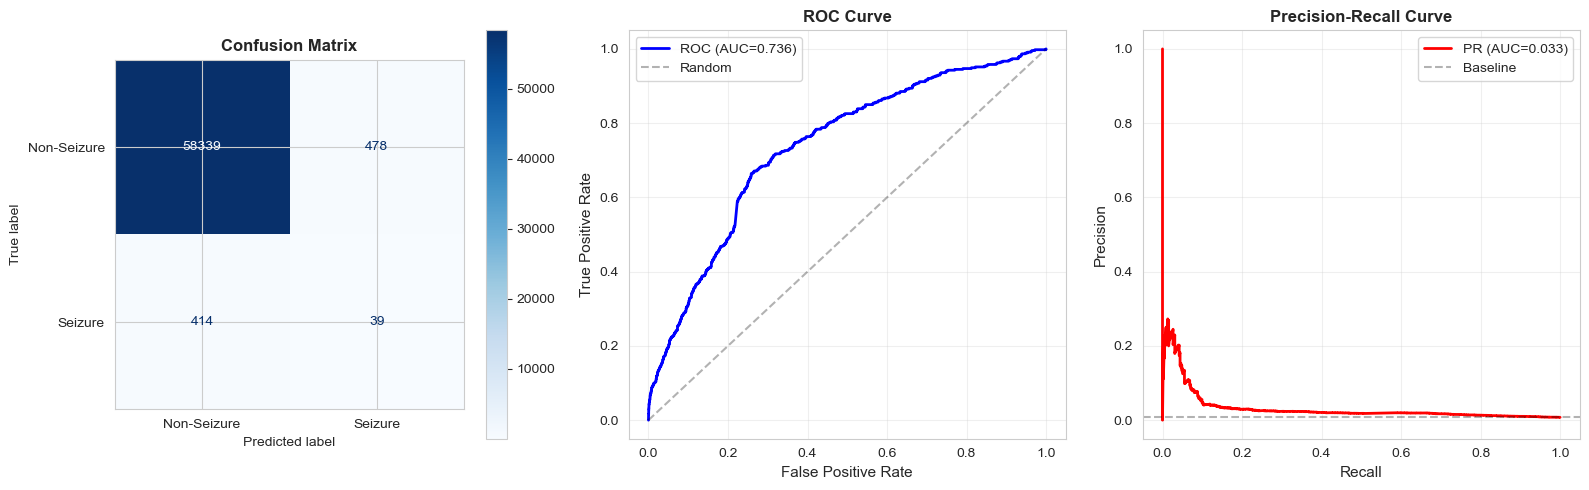


📊 Model Performance Interpretation:
   • True Negatives:  58,339
   • False Positives: 478
   • False Negatives: 414
   • True Positives:  39

   • Specificity: 0.9919 (correctly identifying non-seizures)
   • Sensitivity: 0.0861 (correctly identifying seizures)



In [15]:
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, precision_recall_curve
)

# Final predictions using optimal threshold
y_pred = (y_prob >= best_threshold).astype(int)

# Compute metrics
roc_auc = roc_auc_score(y_true, y_prob)
pr_auc = average_precision_score(y_true, y_prob)

print(f"\n{'='*60}")
print("FINAL MODEL PERFORMANCE (Out-of-Fold)")
print(f"{'='*60}")
print(f"ROC-AUC:        {roc_auc:.4f}")
print(f"PR-AUC:         {pr_auc:.4f}")
print(f"F1 Score:       {best_f1:.4f}")
print(f"Precision:      {best_precision:.4f}")
print(f"Recall:         {best_recall:.4f}")
print(f"Threshold used: {best_threshold:.3f}")
print(f"{'='*60}\n")

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

disp = ConfusionMatrixDisplay(cm, display_labels=['Non-Seizure', 'Seizure'])
disp.plot(ax=axes[0], cmap='Blues')
axes[0].set_title('Confusion Matrix', fontsize=12, fontweight='bold')

# ROC Curve
fpr, tpr, _ = roc_curve(y_true, y_prob)
axes[1].plot(fpr, tpr, 'b-', linewidth=2, label=f'ROC (AUC={roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Random')
axes[1].set_xlabel('False Positive Rate', fontsize=11)
axes[1].set_ylabel('True Positive Rate', fontsize=11)
axes[1].set_title('ROC Curve', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

# Precision-Recall Curve
precision_vals, recall_vals, _ = precision_recall_curve(y_true, y_prob)
axes[2].plot(recall_vals, precision_vals, 'r-', linewidth=2, label=f'PR (AUC={pr_auc:.3f})')
axes[2].axhline(y_true.mean(), color='k', linestyle='--', alpha=0.3, label='Baseline')
axes[2].set_xlabel('Recall', fontsize=11)
axes[2].set_ylabel('Precision', fontsize=11)
axes[2].set_title('Precision-Recall Curve', fontsize=12, fontweight='bold')
axes[2].legend(fontsize=10)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 Model Performance Interpretation:")
tn, fp, fn, tp = cm.ravel()
print(f"   • True Negatives:  {tn:,}")
print(f"   • False Positives: {fp:,}")
print(f"   • False Negatives: {fn:,}")
print(f"   • True Positives:  {tp:,}")
print(f"\n   • Specificity: {tn/(tn+fp):.4f} (correctly identifying non-seizures)")
print(f"   • Sensitivity: {best_recall:.4f} (correctly identifying seizures)\n")

<a id='conclusions'></a>
## 7. Conclusions

### Summary
This notebook demonstrated a complete pipeline for EEG seizure detection:
- Patient-safe cross-validation preventing data leakage
- Memory-efficient streaming data pipeline
- CNN architecture optimized for temporal EEG patterns
- Proper handling of class imbalance

### Clinical Considerations
For clinical deployment, seizure detection systems typically require:
- **High recall (>95%)**: Missing seizures is more critical than false alarms
- **Acceptable precision**: Balance false positives with monitoring burden
- **Patient-specific calibration**: Individual variability in EEG patterns
- **Real-time processing**: Low latency for intervention

### Future Improvements
1. **Architecture enhancements**:
   - Add attention mechanisms for long-range dependencies
   - Try transformer encoders
   - Experiment with time-frequency representations (STFT, wavelets)

2. **Data augmentation**:
   - Time warping
   - Amplitude scaling
   - Synthetic minority oversampling

3. **Calibration**:
   - Temperature scaling for probability calibration
   - Patient-specific fine-tuning

4. **Deployment**:
   - Model quantization for edge devices
   - Real-time inference optimization
   - Continuous learning from new data

### References
- CHB-MIT Scalp EEG Database: https://physionet.org/content/chbmit/1.0.0/
- MNE Python: https://mne.tools/

